In [ ]:
#Fraud Pattern Discovery

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

#load dataset

data = pd.read_csv("creditcard.csv")

# feature engineering

data['Amount'] = data['Amount']

# transaction  between time gap

data['Time gap'] = data['Time'].diff().fillna(0)

# location dervition since no have  info in data

np.random.seed(42)
data['location dervition'] = np.random.uniform(0, 1, size = len(data))

# merchant categories since no have in data list

categories = ['Food', 'Electronics', 'Travel', 'Fashion', 'Misc']
data['merchant categories'] = np.random.choice(categories , size = len(data))

# encode merchant categories

merchant_encoder = pd.get_dummies(data['merchant categories'], prefix = 'MC')

# combine all features

features = pd.concat([data[[
    'Time gap','location dervition', 'Amount']],merchant_encoder], axis = 1)

# StandardScaler

scaler = StandardScaler()
x_scaler = scaler.fit_transform(features)

# hierachical clustering

z = linkage(x_scaler, method = 'ward')

# plot diagram

plt.figure(figsize=(12, 6))
dendrogram(z, truncate_mode = 'level', p = 5)
plt.titile("fraud_pattern discovery using hierachical clustering")
plt.xlabel("transaction")
plt.ylabel("distance")
plt.show()

# extract cluster

clusters = fcluster(z , t = 6 , criteria = 'maxclust')
data[cluster] = cluster

# anlysize clusters

cluster_summary = data.groupby('Cluster').agg({
    'Amount': 'mean',
    'TimeGap': 'mean',
    'LocationDeviation': 'mean'
}).reset_index()


print(cluster_summary)


In [ ]:
#Air Quality Zone Classification

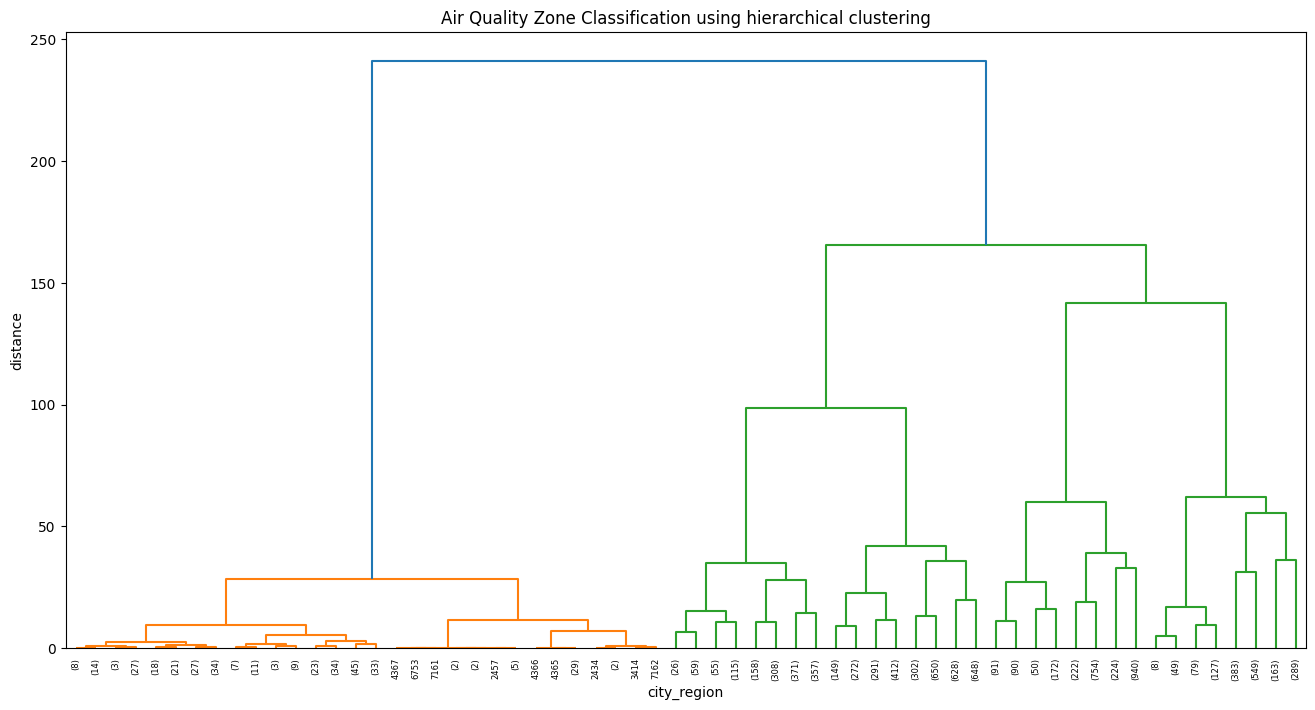

   Cluster          co         No2       PM2.5         ozne
0        1  -17.268852   94.537432 -200.000000  -200.000000
1        2    4.234023  157.262112   21.609404  1640.676501
2        3    2.059845  115.155430   10.108654  1061.862768
3        4    1.022768   37.679434    4.037786   678.700518
4        5 -200.000000 -200.000000   21.511313  1483.388783
5        6 -200.000000 -106.730997    6.889014   825.903601


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster. hierarchy import linkage, dendrogram, fcluster

# load dataset

data = pd.read_excel("AirQualityUCI.xlsx", decimal = ',', na_values=['NA'])

pollutions = data[['CO(GT)', 'NO2(GT)', 'C6H6(GT)', 'PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']]

# rename the coloumns

pollutions = pollutions.rename(columns={
    'CO(GT)':'co',
    'NO2(GT)':'No2',
    'C6H6(GT)':'PM2.5',
    'PT08.S5(O3)':'ozne'
})

pollutions = pollutions.dropna()

# StandardScaler

scaler = StandardScaler()
x_scaler = scaler.fit_transform(pollutions)

# hierarchical clustering

z = linkage(x_scaler, method = 'ward')

# plot diagram

plt.figure(figsize = (16, 8))

dendrogram(z, truncate_mode = 'level', p = 5)

plt.title("Air Quality Zone Classification using hierarchical clustering")

plt.xlabel("city_region")

plt.ylabel("distance")

plt.show()

# extract clsuter

clusters  = fcluster(z, t = 6, criterion = 'maxclust')
pollutions['Cluster']=clusters

# anlysize the clsuter

cluster_summary = pollutions.groupby('Cluster').agg({
     'co':'mean',
     'No2': 'mean',
     'PM2.5':'mean',
     'ozne': 'mean'
}).reset_index()

print(cluster_summary)



In [ ]:
#Vehicle Market Segmentation (Automobile Industry)

   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3                 ?  alfa-romero       gas        std          two   
1          3                 ?  alfa-romero       gas        std          two   
2          1                 ?  alfa-romero       gas        std          two   
3          2               164         audi       gas        std         four   
4          2               164         audi       gas        std         four   

    body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel-system  bore  stroke compression-ratio hor

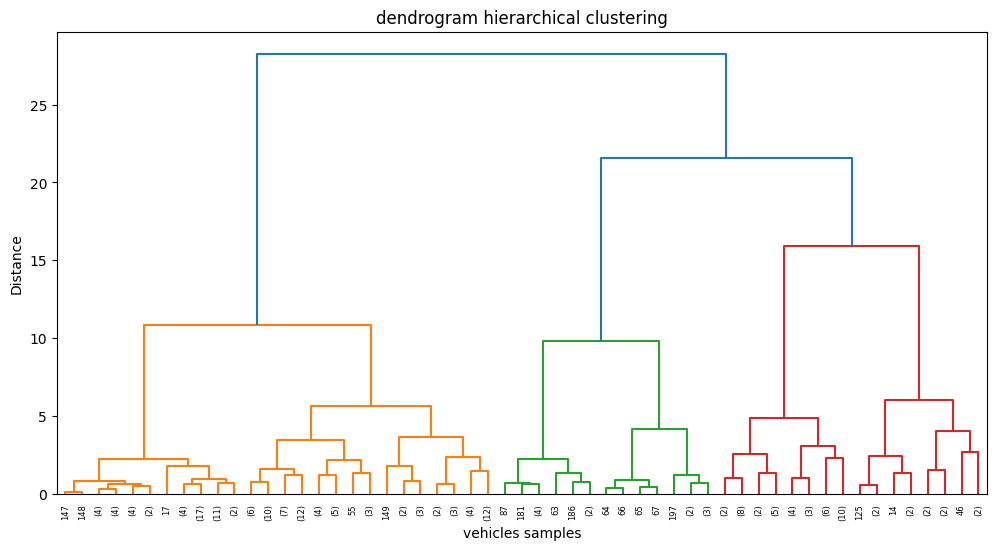

         engine-size  horsepower  curb-weight         price
cluster                                                    
1         105.531746   85.579365  2272.722222   9139.888889
2         135.700000   84.450000  2898.800000  15838.150000
3         174.094340  152.905660  3100.207547  22019.886792


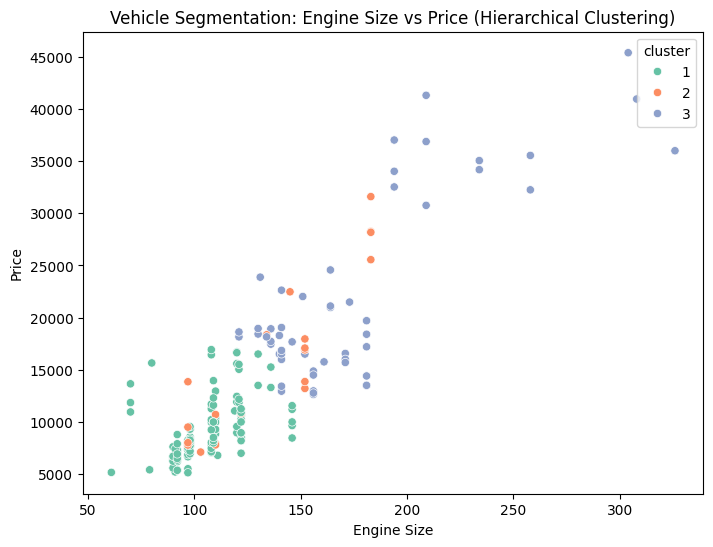

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import seaborn as sns
# load dataset

data = pd.read_csv("Automobile_data.csv")

print(data.head())
print(data.info())

# data cleaning

data.replace("?",np.nan, inplace=True)
data = data.dropna(subset=["price"])

numiercial_col = ["engine-size","horsepower", "curb-weight", "price"]
data[numiercial_col]=data[numiercial_col].apply(lambda col: pd.to_numeric(col, errors="coerce"))

data = data.dropna(subset=numiercial_col)



# convert catilogical data into numical
le = LabelEncoder()
data["fuel-type"] = le.fit_transform(data["fuel-type"])

# features 

features = data[["engine-size","horsepower", "curb-weight", "price","fuel-type"]]

#features scaling

scale = StandardScaler()
x_scaling = scale.fit_transform(features)

# model

model = linkage(x_scaling , method="ward")

# visulization

plt.figure(figsize=(12, 6))
dendrogram(model , truncate_mode= 'level', p = 5 )
plt.title("dendrogram hierarchical clustering")
plt.xlabel("vehicles samples")
plt.ylabel("Distance")
plt.show()

# extract clustering

clusters = fcluster(model, t = 3 , criterion = 'maxclust')
data["cluster"] = clusters

# Cluster Interpretation

cluster_sum = data.groupby("cluster")[numiercial_col].mean()
print(cluster_sum)

# vusliation
plt.figure(figsize=(8,6))
sns.scatterplot(x=data["engine-size"], y=data["price"], hue=data["cluster"], palette="Set2")
plt.title("Vehicle Segmentation: Engine Size vs Price (Hierarchical Clustering)")
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.show()
